In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn import preprocessing
from importlib import reload
import matplotlib as mpl
import scipy
import scipy.stats as stats
import galsim
import tensorflow as tf
from tensorflow.keras import backend as K

sys.path.insert(0,'../../scripts/tools_for_VAE/')
from tools_for_VAE import utils, vae_functions, generator, model, boxplot, plot


%matplotlib inline
%config InlineBackend.figure_format='retina'

KeyboardInterrupt: 

In [3]:
root_dir_v1 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/24.5/test/' 

In [ ]:
images = np.load(root_dir_v1+'img_noiseless_sample_2.npy', mmap_mode = 'c')
psf_img = np.load(root_dir_v1+'psf_cropped_sample_2.npy', mmap_mode = 'c')
data = pd.read_csv(root_dir_v1+'img_noiseless_data_2.csv')

In [ ]:
def lsst_PSF():
    #Fig 1 : https://arxiv.org/pdf/0805.2366.pdf
    mu = -0.43058681997903414 # np.log(0.65)
    sigma = 0.3404334041976153  # Fixed to have corresponding percentils as in paper
    p_unnormed = lambda x : (np.exp(-(np.log(x) - mu)**2 / (2 * sigma**2))
                    / (x * sigma * np.sqrt(2 * np.pi)))#((1/(2*z0))*((z/z0)**2)*np.exp(-z/z0))
    p_normalization = scipy.integrate.quad(p_unnormed, 0., np.inf)[0]
    p = lambda z : p_unnormed(z) / p_normalization

    from scipy import stats
    class PSF_distribution(stats.rv_continuous):
        def __init__(self):
            super(PSF_distribution, self).__init__()
            self.a = 0.
            self.b = 10.
        def _pdf(self, x):
            return p(x)

    pdf = PSF_distribution()
    return pdf.rvs()

In [ ]:
n_images = 10000
image_sheared = np.zeros((4,n_images,59,59,6))
psf_array = np.zeros((4,n_images,59,59,6))
shears = [(0.01,0), (-0.01,0), (0,0.01), (0,-0.01)]

psf_fwhm = [1.01, 0.972, 0.913, 0.841, 0.972, 1.212]

for z, input_shear in enumerate(shears):
    for i in range (n_images):
        for k in range (len(images[0,0,0])):
            psf_image = galsim.Image(psf_img[i,:,:,k], copy=True)
            galsim_psf = galsim.InterpolatedImage(psf_image,scale = 0.2)
            inv_psf = galsim.Deconvolve(galsim_psf)
            
            image_galsim = galsim.Image(images[i,:,:,k], copy=True)
            galsim_obj = galsim.InterpolatedImage(image_galsim,scale = 0.2)
            
            deconv_galsim_obj = galsim.Convolve(inv_psf, galsim_obj)
            
            gamma1 = input_shear[0]
            gamma2 = input_shear[1]
            
            PSF_lsst = galsim.Kolmogorov(fwhm=psf_fwhm[k])
            
            s = galsim.Shear(g1=gamma1,g2=gamma2)

            # Shear PSF object
            psf = PSF_lsst.shear(s)

            # recconvolve by PSF
            conv_galsim_obj = galsim.Convolve(psf, deconv_galsim_obj)
            
            # Reconstruct image from sheared object
            image = galsim.ImageF(59, 59, scale=0.2)
            _ = conv_galsim_obj.drawImage(image=image)
            image_sheared[z,i,:,:,k] = image.array.data
            
            psf_image = galsim.ImageF(59, 59, scale=0.2)
            _ = psf.drawImage(image=psf_image)            
            psf_array[z,i,:,:,k] = psf_image.array.data

In [ ]:
image_sheared.shape, psf_array.shape

In [4]:
root_dir_v1 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/24.5/test/' 

In [ ]:
np.save(root_dir_v1+'psf_sheared_images.npy', image_sheared)
np.save(root_dir_v1+'psf_sheared_PSF.npy', psf_array)

In [5]:
image_sheared = np.load(root_dir_v1+'psf_sheared_images.npy', mmap_mode = 'c')
psf_sheared = np.load(root_dir_v1+'psf_sheared_PSF.npy', mmap_mode = 'c')

### Test networks with and without PSF

In [6]:
######## Parameters
nb_of_bands = 6
batch_size = 128

input_shape = (59, 59, nb_of_bands)
hidden_dim = 256
latent_dim = 32
final_dim = 2
filters = [32,64,128,256]
kernels = [3,3,3,3]

conv_activation = None
dense_activation = None

bands = [0,1,2,3,4,5]

In [7]:
model_concat_one = model.create_model_wo_ls_peak_pooling_concat_one(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)
model_no_psf = model.create_model_wo_ls_peak_pooling_no_psf(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)
model_cyrille = model.create_model_cyrille(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)

W0525 11:50:52.304285 140071478646592 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/ops/resource_variable_ops.py:1635: calling BaseResourceVariable.__init__ (from tensorflow.python.ops.resource_variable_ops) with constraint is deprecated and will be removed in a future version.
Instructions for updating:
If using Keras pass *_constraint arguments to layers.
W0525 11:50:52.898034 140071478646592 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/ops/linalg/linear_operator_lower_triangular.py:158: calling LinearOperator.__init__ (from tensorflow.python.ops.linalg.linear_operator) with graph_parents is deprecated and will be removed in a future version.
Instructions for updating:
Do not pass `graph_parents`.  They will  no longer be used.


In [8]:
root_dir_models = '/sps/lsst/users/barcelin/TFP/weights/test_dc2/'

dir_model_v2 = root_dir_models+'v_test/loss/'#'v14/loss/'  # concat only after all convolution blocks
dir_model_v3 = root_dir_models+'v15/loss/'#'v15/loss/'  # No use of PSF

dir_model_v4 = root_dir_models+'v_cyrille/mse/' # Model cyrille

In [9]:
latest = tf.train.latest_checkpoint(dir_model_v2)
model_concat_one.load_weights(latest)
latest = tf.train.latest_checkpoint(dir_model_v3)
model_no_psf.load_weights(latest)
latest = tf.train.latest_checkpoint(dir_model_v4)
model_cyrille.load_weights(latest)

#### Model without PSF

#### e1

In [9]:
image_sheared.shape, psf_sheared.shape

((4, 10000, 59, 59, 6), (4, 10000, 59, 59, 6))

In [11]:
output_v1 = model_no_psf([tf.cast(image_sheared[0,:2000], tf.float32), tf.cast(psf_sheared[0,:2000], tf.float32)])

e1_out_mean_p001 = K.get_value(output_v1.mean())[:,0]
e2_out_mean_p001 = K.get_value(output_v1.mean())[:,1]

e1_out_std_p001 = K.get_value(output_v1.stddev())[:,0]
e2_out_std_p001 = K.get_value(output_v1.stddev())[:,1]

In [12]:
output_v1 = model_no_psf([tf.cast(image_sheared[1,:2000], tf.float32), tf.cast(psf_sheared[1,:2000], tf.float32)])

e1_out_mean_m001 = K.get_value(output_v1.mean())[:,0]
e2_out_mean_m001 = K.get_value(output_v1.mean())[:,1]

e1_out_std_m001 = K.get_value(output_v1.stddev())[:,0]
e2_out_std_m001 = K.get_value(output_v1.stddev())[:,1]

In [18]:
(np.mean(e1_out_mean_m001)-np.mean(e1_out_mean_p001))

0.0693253640702606

#### Model with PSF

#### e1

In [20]:
output_v1 = model_concat_one([tf.cast(image_sheared[0,:2000], tf.float32), tf.cast(psf_sheared[0,:2000], tf.float32)])

e1_out_mean_p001_with = K.get_value(output_v1.mean())[:,0]
e2_out_mean_p001_with = K.get_value(output_v1.mean())[:,1]

e1_out_std_p001_with = K.get_value(output_v1.stddev())[:,0]
e2_out_std_p001_with = K.get_value(output_v1.stddev())[:,1]

In [23]:
output_v1 = model_concat_one([tf.cast(image_sheared[1,:2000], tf.float32), tf.cast(psf_sheared[1,:2000], tf.float32)])

e1_out_mean_m001_with = K.get_value(output_v1.mean())[:,0]
e2_out_mean_m001_with = K.get_value(output_v1.mean())[:,1]

e1_out_std_m001_with = K.get_value(output_v1.stddev())[:,0]
e2_out_std_m001_with = K.get_value(output_v1.stddev())[:,1]

In [24]:
(np.mean(e1_out_mean_m001_with)-np.mean(e1_out_mean_p001_with))

0.11362737

#### Model Cyrille

#### e1

In [10]:
output_v1 = model_cyrille([tf.cast(image_sheared[0,:2000], tf.float32), tf.cast(psf_sheared[0,:2000], tf.float32)])

mean = K.get_value(output_v1.mean())
std = K.get_value(output_v1.stddev())

e1_out_mean_p001_cyrille = mean[:,0]
e2_out_mean_p001_cyrille = mean[:,1]

e1_out_std_p001_cyrille = std[:,0]
e2_out_std_p001_cyrille = std[:,1]

In [11]:
output_v1 = model_cyrille([tf.cast(image_sheared[1,:2000], tf.float32), tf.cast(psf_sheared[1,:2000], tf.float32)])

mean = K.get_value(output_v1.mean())
std = K.get_value(output_v1.stddev())

e1_out_mean_m001_cyrille = mean[:,0]
e2_out_mean_m001_cyrille = mean[:,1]

e1_out_std_m001_cyrille = std[:,0]
e2_out_std_m001_cyrille = std[:,1]

In [14]:
np.mean(e1_out_mean_m001_with-e1_out_mean_p001_with)

0.084408276

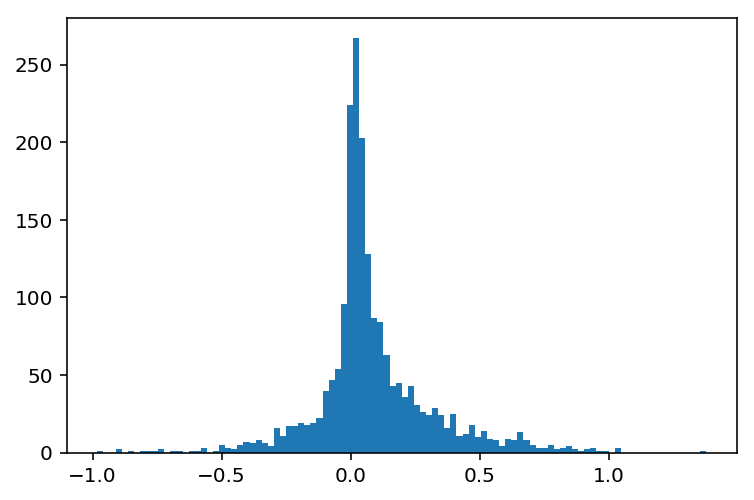

In [15]:
_ = plt.hist(e1_out_mean_m001_with-e1_out_mean_p001_with, bins = 100)

#### $e_2$

In [16]:
output_v1 = model_cyrille([tf.cast(image_sheared[2,:2000], tf.float32), tf.cast(psf_sheared[2,:2000], tf.float32)])

mean = K.get_value(output_v1.mean())
std = K.get_value(output_v1.stddev())

e1_out_mean_0_p001_cyrille = mean[:,0]
e2_out_mean_0_p001_cyrille = mean[:,1]

e1_out_std_0_p001_cyrille = std[:,0]
e2_out_std_0_p001_cyrille = std[:,1]

In [17]:
output_v1 = model_cyrille([tf.cast(image_sheared[3,:2000], tf.float32), tf.cast(psf_sheared[3,:2000], tf.float32)])

mean = K.get_value(output_v1.mean())
std = K.get_value(output_v1.stddev())

e1_out_mean_0_m001_cyrille = mean[:,0]
e2_out_mean_0_m001_cyrille = mean[:,1]

e1_out_std_0_m001_cyrille = std[:,0]
e2_out_std_0_m001_cyrille = std[:,1]

In [20]:
np.mean(e2_out_mean_0_p001_cyrille-e2_out_mean_0_m001_cyrille)

0.097616434

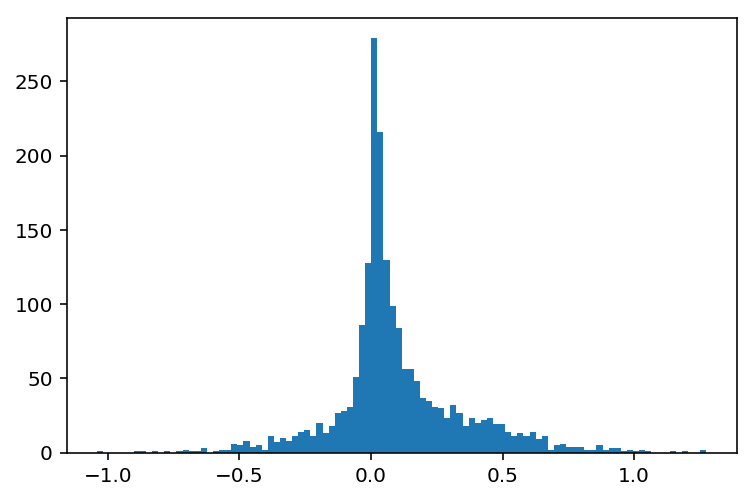

In [21]:
_ = plt.hist(e2_out_mean_0_p001_cyrille-e2_out_mean_0_m001_cyrille, bins = 100)

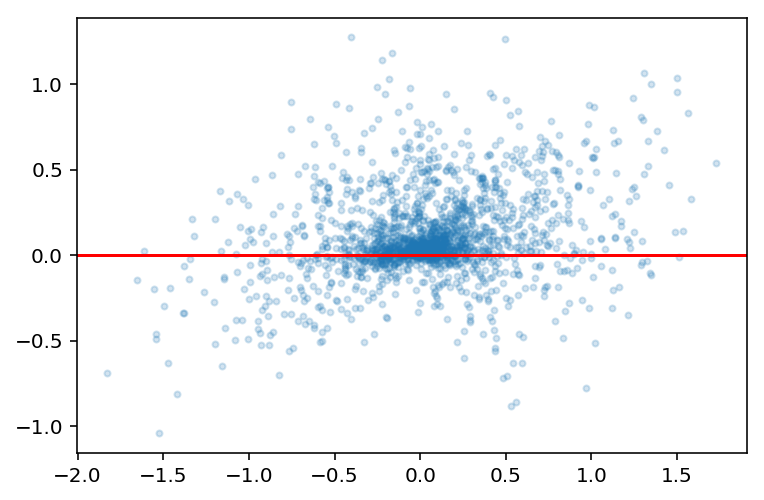

In [24]:
plt.plot(e2_out_mean_0_p001_cyrille, e2_out_mean_0_p001_cyrille-e2_out_mean_0_m001_cyrille, '.', alpha = 0.2)
plt.axhline(0, color = 'r')